# 🔍 Vision Transformers – Didaktisches Notebook
### Kapitel 10 · Bildklassifikation mit Deep Learning

---

Dieses Notebook erklärt das Konzept von Vision Transformers (ViT) **Schritt für Schritt** –  
ohne schwere Berechnungen, mit Fokus auf **Verständnis und Visualisierung**.

**Was Sie in diesem Notebook lernen:**

| Abschnitt | Thema |
|-----------|-------|
| 1 | Motivation: Wo stoßen CNNs an Grenzen? |
| 2 | Patch-Zerlegung: Ein Bild wird zur Token-Sequenz |
| 3 | Positional Embedding: Wo bin ich im Bild? |
| 4 | Self-Attention: Schritt für Schritt mit kleinen Matrizen |
| 5 | CLS-Token: Das Gedächtnis des Transformers |
| 6 | Mini-ViT in Keras: Fashion-MNIST, klein & schnell |
| 7 | Attention Maps: Was schaut das Modell an? |
| 8 | Reflexion & Diskussion |

> **Laufzeit:** ca. 3–5 Minuten auf Google Colab (CPU reicht aus)

---

In [1]:
# ── Erste Zelle im Notebook ──
import time
notebook_start = time.time()
print("Notebook gestartet.")

Notebook gestartet.


## ⚙️ Setup – Bibliotheken laden

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TensorFlow Version: {tf.__version__}')
print(f'NumPy Version:      {np.__version__}')
print('✅ Alle Bibliotheken erfolgreich geladen.')

import random

# Seeds ganz am Anfang setzen
SEED=42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Plot-Stil
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

TensorFlow Version: 2.20.0
NumPy Version:      2.0.2
✅ Alle Bibliotheken erfolgreich geladen.


---
## 1 · Motivation – Wo stoßen CNNs an Grenzen?

Bevor wir Vision Transformers verstehen, brauchen wir ein Gefühl dafür,  
**was CNNs gut können – und was nicht.**

### Das Receptive-Field-Problem

Ein CNN-Filter sieht immer nur einen kleinen lokalen Bereich des Bildes.  
Globaler Kontext entsteht erst nach vielen Schichten – langsam und indirekt.

**Visualisierung:** Wie wächst das Sichtfeld eines CNN-Neurons über die Schichten?

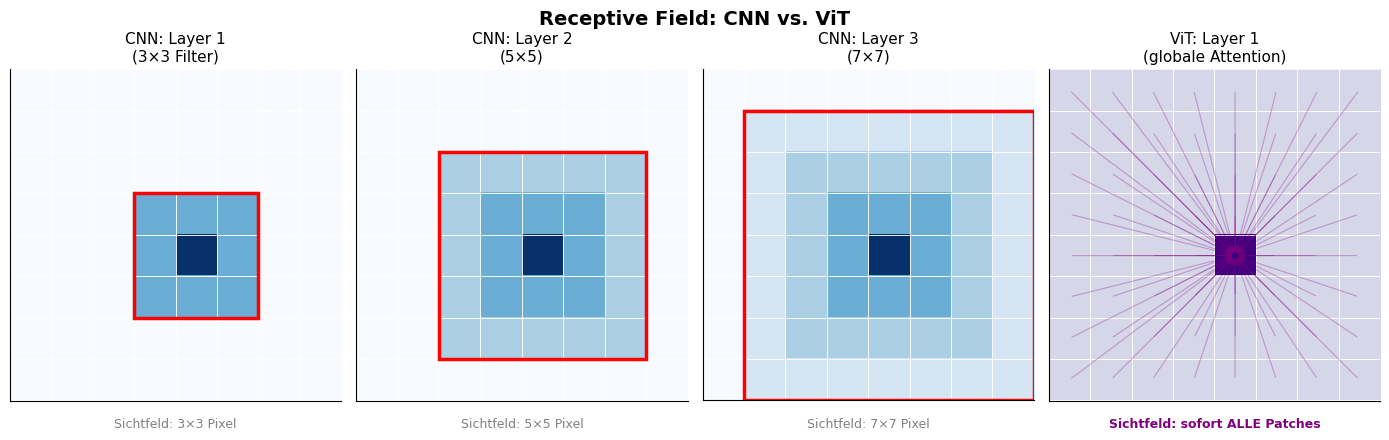

💡 CNNs sehen zu Beginn nur einen kleinen Ausschnitt.
   ViTs sehen sofort das gesamte Bild.


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Receptive Field: CNN vs. ViT', fontsize=14, fontweight='bold', y=1.02)

grid_size = 8
titles_cnn = ['CNN: Layer 1\n(3×3 Filter)', 'CNN: Layer 2\n(5×5)', 'CNN: Layer 3\n(7×7)']
rf_sizes   = [1, 2, 3]   # Radius in Gridfeldern
center     = grid_size // 2

for i, (ax, title, rf) in enumerate(zip(axes[:3], titles_cnn, rf_sizes)):
    grid = np.zeros((grid_size, grid_size))
    for r in range(grid_size):
        for c in range(grid_size):
            dist = max(abs(r - center), abs(c - center))
            if dist <= rf:
                grid[r, c] = 1.0 - dist * 0.25
    grid[center, center] = 1.5

    ax.imshow(grid, cmap='Blues', vmin=0, vmax=1.5)
    for r in range(grid_size):
        for c in range(grid_size):
            ax.add_patch(patches.Rectangle((c-0.5, r-0.5), 1, 1,
                fill=False, edgecolor='white', lw=0.5))
    ax.add_patch(patches.Rectangle((center-rf-0.5, center-rf-0.5),
                 2*rf+1, 2*rf+1, fill=False, edgecolor='red', lw=2.5))
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, -0.08, f'Sichtfeld: {(2*rf+1)}×{(2*rf+1)} Pixel',
            transform=ax.transAxes, ha='center', fontsize=9, color='gray')

# ViT: sofort global
ax_vit = axes[3]
grid_vit = np.ones((grid_size, grid_size)) * 0.4
grid_vit[center, center] = 1.5
ax_vit.imshow(grid_vit, cmap='Purples', vmin=0, vmax=1.5)
for r in range(grid_size):
    for c in range(grid_size):
        ax_vit.add_patch(patches.Rectangle((c-0.5, r-0.5), 1, 1,
            fill=False, edgecolor='white', lw=0.5))
        if not (r == center and c == center):
            ax_vit.annotate('', xy=(center, center), xytext=(c, r),
                arrowprops=dict(arrowstyle='->', color='purple', alpha=0.3, lw=0.8))
ax_vit.set_title('ViT: Layer 1\n(globale Attention)', fontsize=11)
ax_vit.set_xticks([]); ax_vit.set_yticks([])
ax_vit.text(0.5, -0.08, 'Sichtfeld: sofort ALLE Patches',
            transform=ax_vit.transAxes, ha='center', fontsize=9, color='purple', fontweight='bold')

plt.tight_layout()
plt.show()
print('💡 CNNs sehen zu Beginn nur einen kleinen Ausschnitt.')
print('   ViTs sehen sofort das gesamte Bild.')

---
## 2 · Patch-Zerlegung – Ein Bild wird zur Token-Sequenz

### Die Kernidee
Statt ein Bild Pixel für Pixel oder mit Faltungsfiltern zu verarbeiten,  
zerlegt ViT das Bild in **gleichgroße Rechtecke (Patches)** –  
und behandelt jeden Patch wie ein **Wort in einem Satz**.

```
Bild (224×224)  →  Patches (16×16)  →  196 Tokens
                                         ↓
                              wie 196 Wörter in BERT
```

**Wir zeigen das mit einem echten Fashion-MNIST-Bild (28×28, Patch-Größe 7×7 → 16 Patches).**

In [4]:
# Fashion-MNIST laden (klein, gut zum Erklären)
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
class_names = ['T-Shirt', 'Hose', 'Pullover', 'Kleid', 'Mantel',
                'Sandale', 'Hemd', 'Sneaker', 'Tasche', 'Stiefelette']

# Normalisierung
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

print(f'Trainingsdaten:  {X_train.shape}  →  {X_train.shape[0]} Bilder à 28×28 Pixel')
print(f'Testdaten:       {X_test.shape}')
print(f'Klassen:         {class_names}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainingsdaten:  (60000, 28, 28)  →  60000 Bilder à 28×28 Pixel
Testdaten:       (10000, 28, 28)
Klassen:         ['T-Shirt', 'Hose', 'Pullover', 'Kleid', 'Mantel', 'Sandale', 'Hemd', 'Sneaker', 'Tasche', 'Stiefelette']


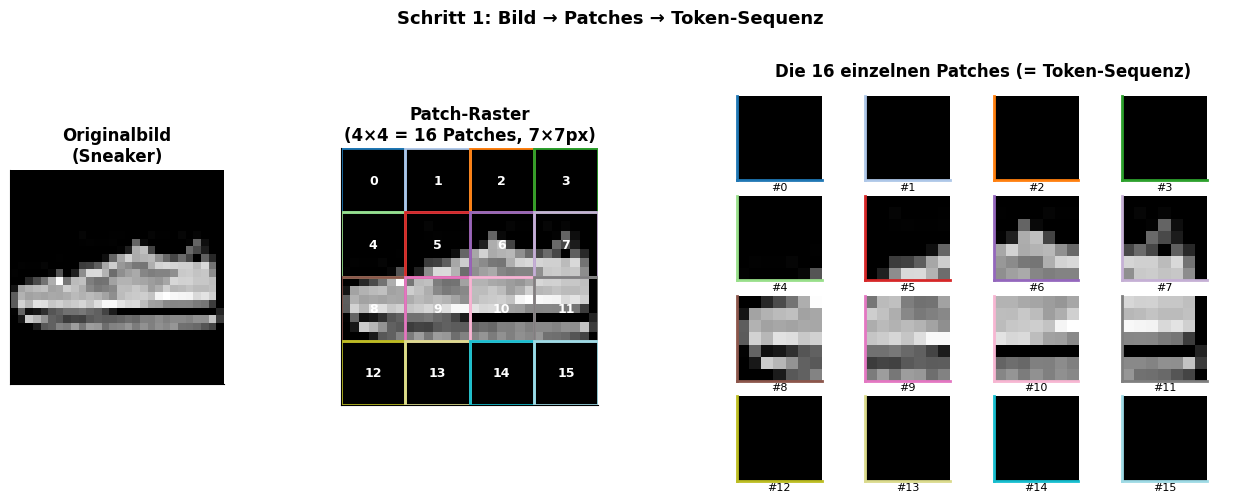


📐 Patch-Statistik:
   Bildgröße:      28×28 Pixel
   Patch-Größe:    7×7 Pixel
   Anzahl Patches: 16 (= Token-Sequenzlänge)
   Patch als Vektor (Flatten): 49 Werte


In [5]:
# ── Patch-Zerlegung visualisieren ────────────────────────────────────────────
PATCH_SIZE = 7   # 28×28 Bild → 4×4 = 16 Patches
IMG_SIZE   = 28
N_PATCHES  = (IMG_SIZE // PATCH_SIZE) ** 2

# Ein Beispielbild auswählen (Sneaker)
idx = np.where(y_train == 7)[0][3]
img = X_train[idx]  # (28, 28)

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, width_ratios=[1, 1.2, 2.5], wspace=0.35)

# --- Panel 1: Originalbild ---
ax0 = fig.add_subplot(gs[0])
ax0.imshow(img, cmap='gray', vmin=0, vmax=1)
ax0.set_title(f'Originalbild\n({class_names[y_train[idx]]})', fontsize=12, fontweight='bold')
ax0.set_xticks([]); ax0.set_yticks([])

# --- Panel 2: Bild mit Patch-Raster ---
ax1 = fig.add_subplot(gs[1])
ax1.imshow(img, cmap='gray', vmin=0, vmax=1)
n = IMG_SIZE // PATCH_SIZE
colors_grid = plt.cm.tab20(np.linspace(0, 1, N_PATCHES))
patch_num = 0
for row in range(n):
    for col in range(n):
        x = col * PATCH_SIZE
        y = row * PATCH_SIZE
        rect = patches.Rectangle((x - 0.5, y - 0.5), PATCH_SIZE, PATCH_SIZE,
                                  linewidth=2, edgecolor=colors_grid[patch_num],
                                  facecolor='none')
        ax1.add_patch(rect)
        ax1.text(x + PATCH_SIZE/2 - 0.5, y + PATCH_SIZE/2 - 0.5,
                 str(patch_num), ha='center', va='center',
                 fontsize=9, color='white', fontweight='bold')
        patch_num += 1
ax1.set_title(f'Patch-Raster\n({n}×{n} = {N_PATCHES} Patches, {PATCH_SIZE}×{PATCH_SIZE}px)', fontsize=12, fontweight='bold')
ax1.set_xticks([]); ax1.set_yticks([])

# --- Panel 3: Alle Patches einzeln ---
ax2 = fig.add_subplot(gs[2])
ax2.axis('off')
ax2.set_title(f'Die {N_PATCHES} einzelnen Patches (= Token-Sequenz)', fontsize=12, fontweight='bold')

patch_idx = 0
for row in range(n):
    for col in range(n):
        r = row * PATCH_SIZE
        c = col * PATCH_SIZE
        patch = img[r:r+PATCH_SIZE, c:c+PATCH_SIZE]

        # Position im Figure-Panel
        px = 0.02 + col * 0.24
        py = 0.75 - row * 0.26

        ax_patch = fig.add_axes([gs[2].get_position(fig).x0 + px * gs[2].get_position(fig).width,
                                  gs[2].get_position(fig).y0 + py * gs[2].get_position(fig).height,
                                  0.20 * gs[2].get_position(fig).width,
                                  0.22 * gs[2].get_position(fig).height])
        ax_patch.imshow(patch, cmap='gray', vmin=0, vmax=1)
        for sp in ax_patch.spines.values():
            sp.set_edgecolor(colors_grid[patch_idx])
            sp.set_linewidth(2)
        ax_patch.set_xticks([]); ax_patch.set_yticks([])
        ax_patch.set_xlabel(f'#{patch_idx}', fontsize=8, labelpad=1)
        patch_idx += 1

plt.suptitle('Schritt 1: Bild → Patches → Token-Sequenz', fontsize=13, fontweight='bold', y=1.03)
plt.show()

print(f'\n📐 Patch-Statistik:')
print(f'   Bildgröße:      {IMG_SIZE}×{IMG_SIZE} Pixel')
print(f'   Patch-Größe:    {PATCH_SIZE}×{PATCH_SIZE} Pixel')
print(f'   Anzahl Patches: {N_PATCHES} (= Token-Sequenzlänge)')
print(f'   Patch als Vektor (Flatten): {PATCH_SIZE*PATCH_SIZE} Werte')

---
## 3 · Patch Embedding – Patches werden zu Vektoren

Jeder Patch (7×7 = 49 Pixelwerte) wird durch eine **lineare Projektion**  
in einen kompakten **Embedding-Vektor** der Dimension `d` umgewandelt.

```
Patch  (7×7×1 = 49 Werte)
   ↓  Flatten
Vektor (49,)
   ↓  Lineare Projektion  W ∈ ℝ^(49×d)
Embedding (d,)    ← dieser wird in den Transformer gespeist
```

> **Wichtig:** Die Projektionsmatrix `W` wird **gelernt** – nicht vorgegeben.
> Das Modell lernt selbst, welche Aspekte eines Patches wichtig sind.

In Keras implementieren wir das mit einem `Dense`-Layer nach dem `Reshape`.

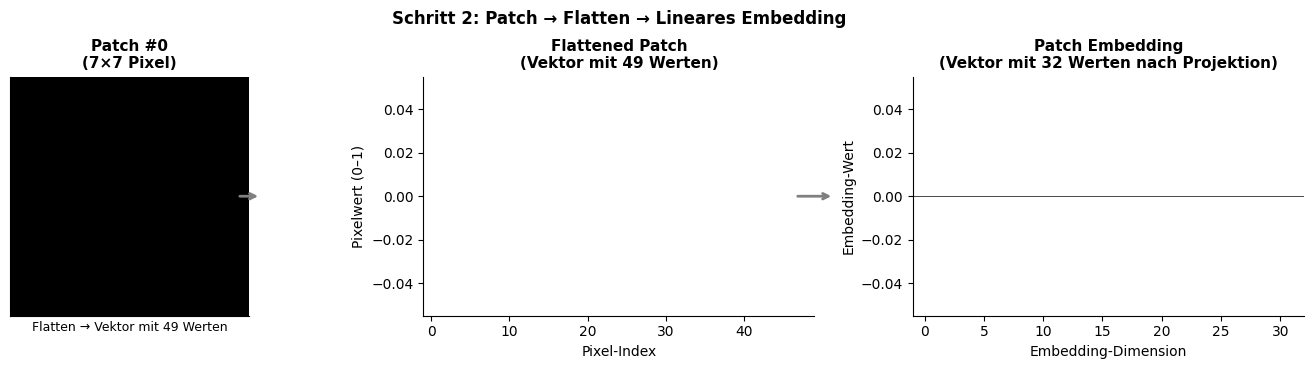


📊 Dimensionen:
   Patch (Rohdaten):  7×7 = 49 Werte
   Projektionsmatrix: (49, 32)
   Embedding-Vektor:  (32,)  ← kompakte Repräsentation
   Alle 16 Patches → Matrix der Form (16, 32)


In [6]:
# ── Patch Embedding visuell erklären ─────────────────────────────────────────
D_MODEL = 32   # Embedding-Dimension (klein für Demo)

# Manuelles Embedding eines einzelnen Patches
patch_0 = img[0:PATCH_SIZE, 0:PATCH_SIZE].flatten()  # (49,)
W_proj  = np.random.randn(len(patch_0), D_MODEL) * 0.1  # (49, 32)
embed_0 = patch_0 @ W_proj  # (32,)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

# Patch visualisieren
axes[0].imshow(img[0:PATCH_SIZE, 0:PATCH_SIZE], cmap='gray')
axes[0].set_title(f'Patch #0\n({PATCH_SIZE}×{PATCH_SIZE} Pixel)', fontsize=11, fontweight='bold')
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[0].set_xlabel(f'Flatten → Vektor mit {PATCH_SIZE*PATCH_SIZE} Werten', fontsize=9)

# Flattened Vektor
axes[1].bar(range(len(patch_0)), patch_0, color='steelblue', alpha=0.7, width=1.0)
axes[1].set_title(f'Flattened Patch\n(Vektor mit {len(patch_0)} Werten)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Pixel-Index')
axes[1].set_ylabel('Pixelwert (0–1)')
axes[1].set_xlim(-1, len(patch_0))

# Embedding Vektor
axes[2].bar(range(D_MODEL), embed_0, color='darkorange', alpha=0.8, width=0.8)
axes[2].axhline(0, color='black', lw=0.5)
axes[2].set_title(f'Patch Embedding\n(Vektor mit {D_MODEL} Werten nach Projektion)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Embedding-Dimension')
axes[2].set_ylabel('Embedding-Wert')
axes[2].set_xlim(-1, D_MODEL)

# Pfeile zwischen den Plots
for ax in axes[:2]:
    ax.annotate('', xy=(1.05, 0.5), xycoords='axes fraction',
                xytext=(0.95, 0.5),
                arrowprops=dict(arrowstyle='->', lw=2, color='gray'))

plt.tight_layout()
plt.suptitle('Schritt 2: Patch → Flatten → Lineares Embedding', fontsize=12, fontweight='bold', y=1.04)
plt.show()

print(f'\n📊 Dimensionen:')
print(f'   Patch (Rohdaten):  {PATCH_SIZE}×{PATCH_SIZE} = {PATCH_SIZE*PATCH_SIZE} Werte')
print(f'   Projektionsmatrix: ({PATCH_SIZE*PATCH_SIZE}, {D_MODEL})')
print(f'   Embedding-Vektor:  ({D_MODEL},)  ← kompakte Repräsentation')
print(f'   Alle {N_PATCHES} Patches → Matrix der Form ({N_PATCHES}, {D_MODEL})')

---
## 4 · Positional Embedding – Wo bin ich im Bild?

Der Transformer selbst hat **kein Gedächtnis für Reihenfolge**.  
Ohne Zusatzinformation würde er Patches als eine **ungeordnete Menge** behandeln –  
Patch #0 links oben und Patch #15 rechts unten wären nicht unterscheidbar.

**Lösung:** Jeder Patch-Embedding-Vektor bekommt einen **Positions-Vektor addiert**,  
der gelernt wird und die räumliche Position kodiert.

```
Token-i  =  Patch-Embedding-i  +  Positional-Embedding-i
```

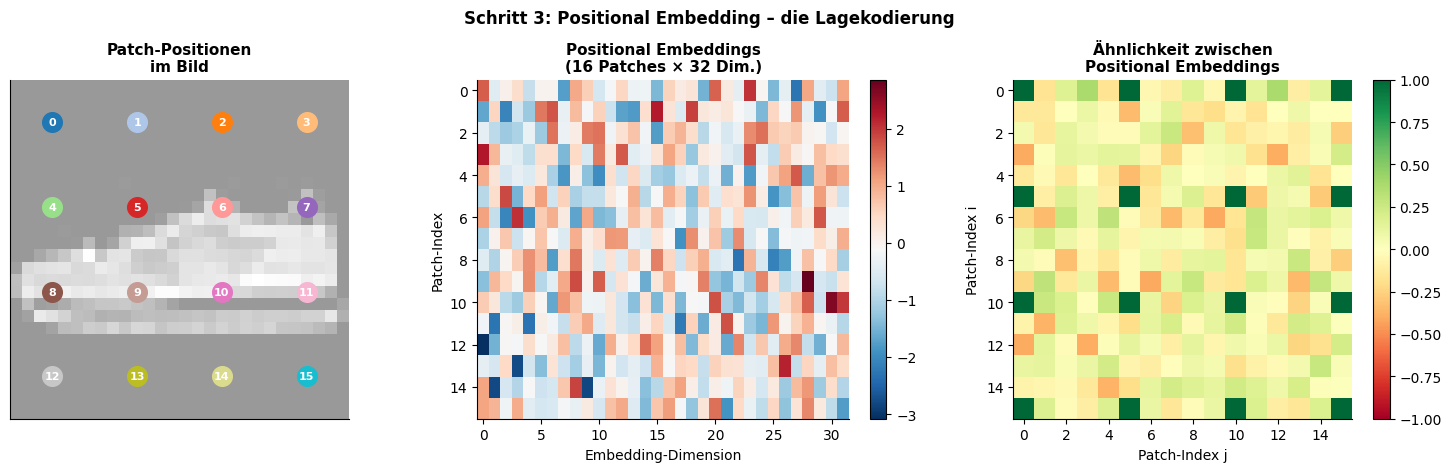

💡 Nach dem Training sollten räumlich nah beieinander liegende Patches
   ähnlichere Positional Embeddings haben – das Modell lernt die Geometrie.


In [7]:
# ── Positional Embeddings visualisieren ──────────────────────────────────────
# Simulierte gelernte Positional Embeddings (normalerweise durch Training gelernt)
np.random.seed(7)
pos_emb = np.random.randn(N_PATCHES, D_MODEL)  # (16, 32)

# Ähnlichkeit zwischen den Positional Embeddings berechnen
norms = np.linalg.norm(pos_emb, axis=1, keepdims=True)
pos_emb_norm = pos_emb / (norms + 1e-8)
similarity = pos_emb_norm @ pos_emb_norm.T  # Cosine-Ähnlichkeit

n_grid = IMG_SIZE // PATCH_SIZE

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: Position der Patches im Bild
axes[0].imshow(img, cmap='gray', alpha=0.4)
for i in range(N_PATCHES):
    row = i // n_grid
    col = i  % n_grid
    cx = col * PATCH_SIZE + PATCH_SIZE / 2
    cy = row * PATCH_SIZE + PATCH_SIZE / 2
    axes[0].scatter(cx - 0.5, cy - 0.5, s=200, c=[plt.cm.tab20(i/N_PATCHES)], zorder=5)
    axes[0].text(cx - 0.5, cy - 0.5, str(i), ha='center', va='center',
                 fontsize=8, fontweight='bold', color='white', zorder=6)
axes[0].set_title('Patch-Positionen\nim Bild', fontsize=11, fontweight='bold')
axes[0].set_xticks([]); axes[0].set_yticks([])

# Panel 2: Positional Embedding Heatmap
im2 = axes[1].imshow(pos_emb, cmap='RdBu_r', aspect='auto')
axes[1].set_title(f'Positional Embeddings\n({N_PATCHES} Patches × {D_MODEL} Dim.)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Embedding-Dimension')
axes[1].set_ylabel('Patch-Index')
plt.colorbar(im2, ax=axes[1], fraction=0.046)

# Panel 3: Ähnlichkeits-Matrix (räumlich nah = ähnlicher Positional Embedding)
im3 = axes[2].imshow(similarity.reshape(n_grid, n_grid, n_grid, n_grid)
                                .transpose(0, 2, 1, 3)
                                .reshape(N_PATCHES, N_PATCHES),
                      cmap='RdYlGn', vmin=-1, vmax=1)
axes[2].set_title('Ähnlichkeit zwischen\nPositional Embeddings', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Patch-Index j')
axes[2].set_ylabel('Patch-Index i')
plt.colorbar(im3, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.suptitle('Schritt 3: Positional Embedding – die Lagekodierung', fontsize=12, fontweight='bold', y=1.04)
plt.show()

print('💡 Nach dem Training sollten räumlich nah beieinander liegende Patches')
print('   ähnlichere Positional Embeddings haben – das Modell lernt die Geometrie.')

---
## 5 · Self-Attention – Schritt für Schritt

Self-Attention ist das Herzstück des Transformers. Wir rechnen es jetzt  
**manuell mit kleinen Matrizen** durch – so wird die Formel greifbar:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

### Was passiert dabei?

1. **Q, K, V erzeugen:** Jeder Token-Vektor wird durch 3 gelernte Matrizen projiziert
2. **Scores berechnen:** Q·Kᵀ – wie gut passt Token i zu Token j?
3. **Skalieren:** Division durch √d_k – verhindert zu extreme Softmax-Werte
4. **Softmax:** Attention-Gewichte (summieren auf 1)
5. **Weighted Sum:** Gewichtete Summe der V-Vektoren

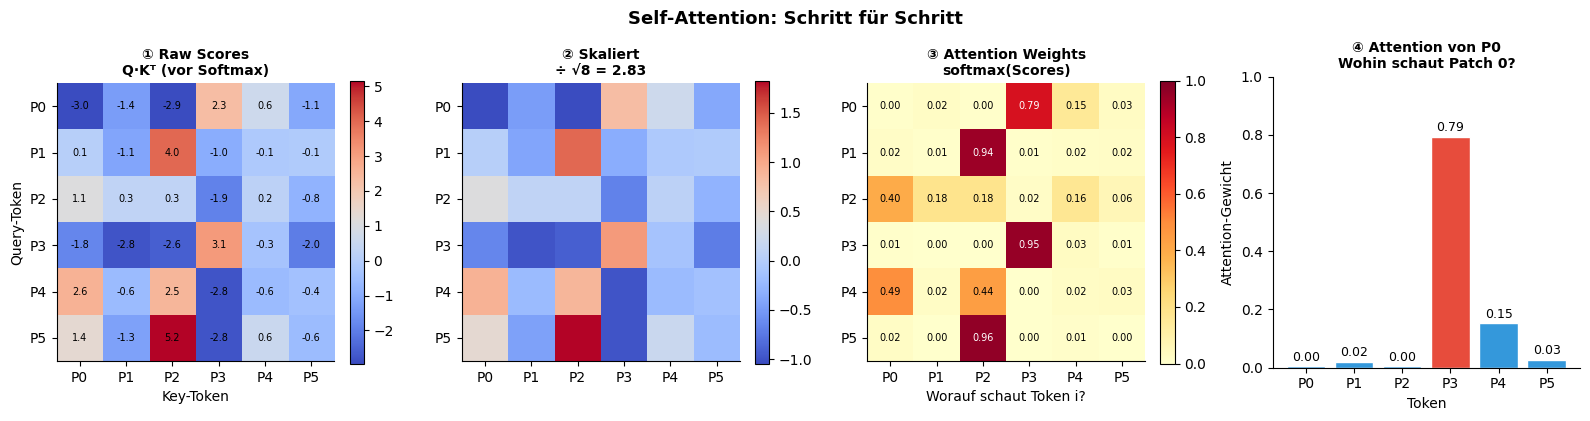


💡 Interpretation der Attention-Gewichte:
   Patch 0 schaut am stärksten auf Patch 3
   (Attention-Gewicht: 0.792)
   → Nach dem Training spiegeln diese Gewichte semantische Ähnlichkeiten wider.


In [8]:
# ── Self-Attention Schritt für Schritt ───────────────────────────────────────
# Vereinfachtes Beispiel: 4 Tokens, d=4
N_TOKENS = 6
D_K      = 8   # Attention-Dimension

np.random.seed(21)
# Simulierte Token-Sequenz (z.B. 6 Patches als Vektoren)
tokens = np.random.randn(N_TOKENS, D_K)

# Gelernte Projektionsmatrizen W_Q, W_K, W_V
W_Q = np.random.randn(D_K, D_K) * 0.5
W_K = np.random.randn(D_K, D_K) * 0.5
W_V = np.random.randn(D_K, D_K) * 0.5

# Schritt 1: Q, K, V berechnen
Q = tokens @ W_Q   # (N_TOKENS, D_K)
K = tokens @ W_K
V = tokens @ W_V

# Schritt 2+3: Scores berechnen und skalieren
scores = Q @ K.T / np.sqrt(D_K)  # (N_TOKENS, N_TOKENS)

# Schritt 4: Softmax
def softmax(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

attention_weights = softmax(scores)  # (N_TOKENS, N_TOKENS)

# Schritt 5: Output
output = attention_weights @ V  # (N_TOKENS, D_K)

# ── Visualisierung ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
patch_labels = [f'P{i}' for i in range(N_TOKENS)]

# Raw Scores
im0 = axes[0].imshow(scores, cmap='coolwarm')
axes[0].set_title('① Raw Scores\nQ·Kᵀ (vor Softmax)', fontsize=10, fontweight='bold')
axes[0].set_xticks(range(N_TOKENS)); axes[0].set_yticks(range(N_TOKENS))
axes[0].set_xticklabels(patch_labels); axes[0].set_yticklabels(patch_labels)
axes[0].set_xlabel('Key-Token'); axes[0].set_ylabel('Query-Token')
plt.colorbar(im0, ax=axes[0], fraction=0.046)
for i in range(N_TOKENS):
    for j in range(N_TOKENS):
        axes[0].text(j, i, f'{scores[i,j]:.1f}', ha='center', va='center', fontsize=7)

# Skalierte Scores
im1 = axes[1].imshow(scores / np.sqrt(D_K), cmap='coolwarm')
axes[1].set_title(f'② Skaliert\n÷ √{D_K} = {np.sqrt(D_K):.2f}', fontsize=10, fontweight='bold')
axes[1].set_xticks(range(N_TOKENS)); axes[1].set_yticks(range(N_TOKENS))
axes[1].set_xticklabels(patch_labels); axes[1].set_yticklabels(patch_labels)
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Attention Weights
im2 = axes[2].imshow(attention_weights, cmap='YlOrRd', vmin=0, vmax=1)
axes[2].set_title('③ Attention Weights\nsoftmax(Scores)', fontsize=10, fontweight='bold')
axes[2].set_xticks(range(N_TOKENS)); axes[2].set_yticks(range(N_TOKENS))
axes[2].set_xticklabels(patch_labels); axes[2].set_yticklabels(patch_labels)
axes[2].set_xlabel('Worauf schaut Token i?')
plt.colorbar(im2, ax=axes[2], fraction=0.046)
for i in range(N_TOKENS):
    for j in range(N_TOKENS):
        axes[2].text(j, i, f'{attention_weights[i,j]:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if attention_weights[i,j] > 0.5 else 'black')

# Aufmerksamkeit von Token 0 im Detail
colors_bar = ['#E74C3C' if w == attention_weights[0].max() else '#3498DB'
              for w in attention_weights[0]]
axes[3].bar(patch_labels, attention_weights[0], color=colors_bar, edgecolor='white', lw=1)
axes[3].set_title(f'④ Attention von P0\nWohin schaut Patch 0?', fontsize=10, fontweight='bold')
axes[3].set_ylabel('Attention-Gewicht')
axes[3].set_xlabel('Token')
axes[3].set_ylim(0, 1)
for i, w in enumerate(attention_weights[0]):
    axes[3].text(i, w + 0.02, f'{w:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Self-Attention: Schritt für Schritt', fontsize=13, fontweight='bold', y=1.04)
plt.show()

print('\n💡 Interpretation der Attention-Gewichte:')
most_attended = np.argmax(attention_weights[0])
print(f'   Patch 0 schaut am stärksten auf Patch {most_attended}')
print(f'   (Attention-Gewicht: {attention_weights[0, most_attended]:.3f})')
print('   → Nach dem Training spiegeln diese Gewichte semantische Ähnlichkeiten wider.')

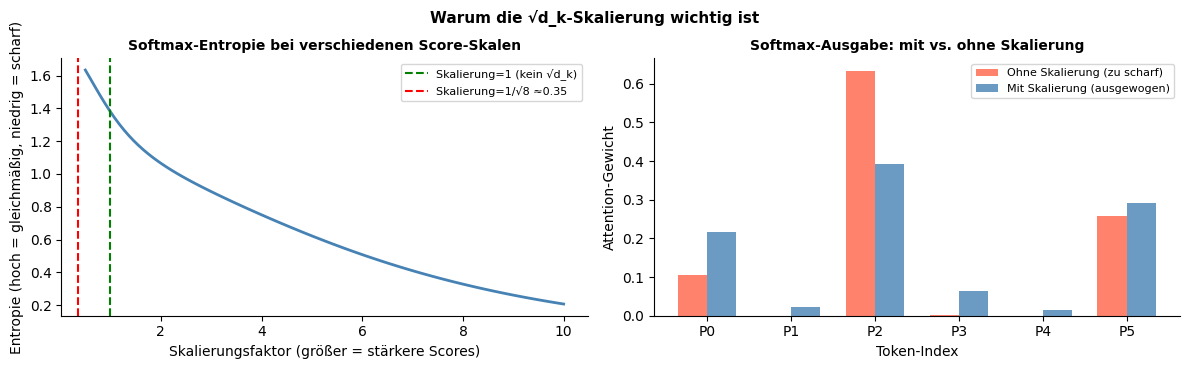

💡 Ohne Skalierung: Softmax wird sehr scharf → Fast-Null-Gradienten → Training bricht zusammen.
   Mit 1/√d_k Skalierung: Softmax bleibt ausgewogen → stabiles Training.


In [9]:
# ── Warum muss man skalieren? (Intuition) ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

d_values   = [1, 2, 4, 8, 16, 32, 64]
raw_scores = np.array([1.5, -0.8, 2.1, 0.3, -1.2, 1.8])

for d in d_values:
    sw_raw    = softmax(raw_scores * np.sqrt(d))
    sw_scaled = softmax(raw_scores)

# Softmax bei verschiedenen Score-Skalen
scales = np.linspace(0.5, 10, 100)
entropies = []
for s in scales:
    sw = softmax(raw_scores * s)
    ent = -np.sum(sw * np.log(sw + 1e-10))
    entropies.append(ent)

axes[0].plot(scales, entropies, color='steelblue', lw=2)
axes[0].axvline(x=1.0, color='green', ls='--', lw=1.5, label='Skalierung=1 (kein √d_k)')
axes[0].axvline(x=1/np.sqrt(D_K), color='red', ls='--', lw=1.5, label=f'Skalierung=1/√{D_K} ≈{1/np.sqrt(D_K):.2f}')
axes[0].set_title('Softmax-Entropie bei verschiedenen Score-Skalen', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Skalierungsfaktor (größer = stärkere Scores)')
axes[0].set_ylabel('Entropie (hoch = gleichmäßig, niedrig = scharf)')
axes[0].legend(fontsize=8)

# Vergleich: skaliert vs. nicht skaliert
x  = np.arange(len(raw_scores))
sw_no_scale  = softmax(raw_scores * 3.0)  # zu große Scores
sw_with_scale = softmax(raw_scores)        # angemessen skaliert
w = 0.35
axes[1].bar(x - w/2, sw_no_scale,   w, label='Ohne Skalierung (zu scharf)', color='tomato',    alpha=0.8)
axes[1].bar(x + w/2, sw_with_scale, w, label='Mit Skalierung (ausgewogen)',  color='steelblue', alpha=0.8)
axes[1].set_title('Softmax-Ausgabe: mit vs. ohne Skalierung', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Token-Index'); axes[1].set_ylabel('Attention-Gewicht')
axes[1].legend(fontsize=8); axes[1].set_xticks(x)
axes[1].set_xticklabels([f'P{i}' for i in range(len(raw_scores))])

plt.tight_layout()
plt.suptitle('Warum die √d_k-Skalierung wichtig ist', fontsize=11, fontweight='bold', y=1.04)
plt.show()

print('💡 Ohne Skalierung: Softmax wird sehr scharf → Fast-Null-Gradienten → Training bricht zusammen.')
print('   Mit 1/√d_k Skalierung: Softmax bleibt ausgewogen → stabiles Training.')

---
## 6 · CLS-Token – Das Gedächtnis des Transformers

Der CLS-Token (Classification Token) ist ein **spezieller, zusätzlicher Token**,  
der am Anfang der Patch-Sequenz eingefügt wird.

```
[CLS] | Patch_0 | Patch_1 | ... | Patch_15
   ↑
   Interagiert via Self-Attention mit ALLEN Patches
   → Sammelt globale Information aus dem gesamten Bild
   → Sein Output-Vektor wird für die Klassifikation genutzt
```

**Warum funktioniert das?**  
Durch Self-Attention kann der CLS-Token von jedem anderen Token Information anfordern.  
Nach L Transformer-Blöcken hat er alle relevanten Informationen akkumuliert.

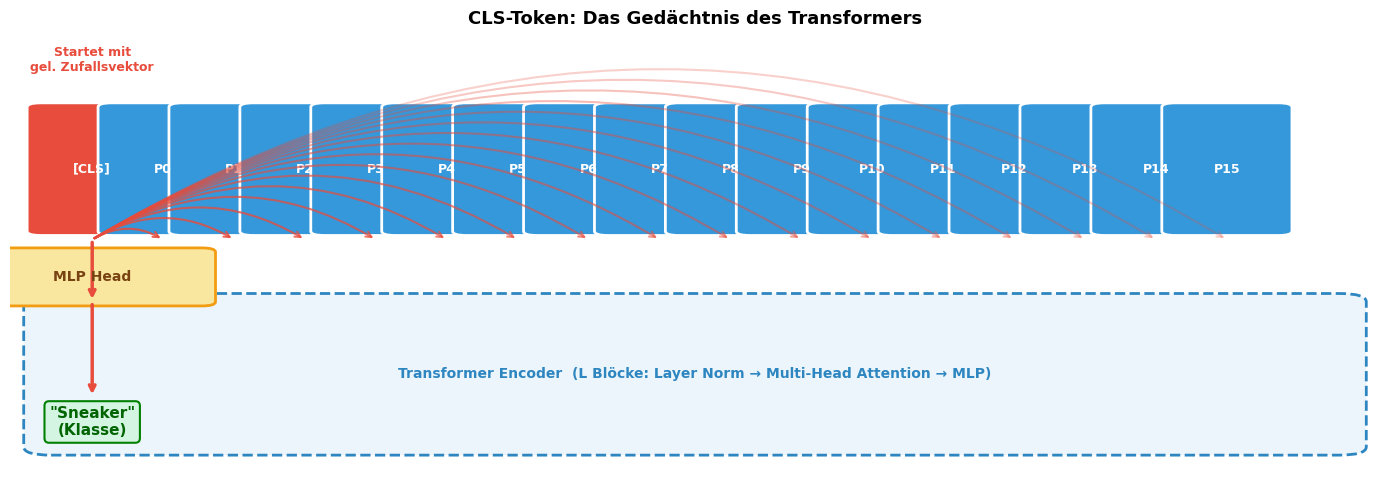

💡 Der CLS-Token interagiert durch Self-Attention mit allen Patches.
   Am Ende des Encoders repräsentiert er das gesamte Bild.
   Sein Vektor wird vom MLP Head für die finale Klassifikation genutzt.


In [10]:
# ── CLS-Token Konzept visualisieren ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

total_tokens = N_PATCHES + 1  # inkl. CLS
token_colors = ['#E74C3C'] + ['#3498DB'] * N_PATCHES  # CLS = rot, Patches = blau
token_labels = ['[CLS]'] + [f'P{i}' for i in range(N_PATCHES)]

# Token-Boxen zeichnen
box_width, box_height = 0.075, 0.3
y_top = 0.75
spacing = 0.88 / total_tokens
x_start = 0.06

positions = []
for i in range(total_tokens):
    x = x_start + i * spacing
    positions.append(x)
    rect = patches.FancyBboxPatch((x - box_width/2, y_top - box_height/2),
                                   box_width, box_height,
                                   boxstyle='round,pad=0.01',
                                   facecolor=token_colors[i], edgecolor='white', lw=2)
    ax.add_patch(rect)
    ax.text(x, y_top, token_labels[i], ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')

# Attention-Pfeile vom CLS zu allen anderen
cls_x = positions[0]
for i in range(1, total_tokens):
    alpha = 0.9 - i * 0.04
    ax.annotate('',
        xy=(positions[i], y_top - box_height/2 - 0.02),
        xytext=(cls_x, y_top - box_height/2 - 0.02),
        arrowprops=dict(arrowstyle='->', color='#E74C3C',
                        lw=1.5, alpha=max(0.2, alpha),
                        connectionstyle='arc3,rad=-0.3'))

# Legende
ax.text(cls_x, y_top + box_height/2 + 0.08, 'Startet mit\ngel. Zufallsvektor',
        ha='center', va='bottom', fontsize=9, color='#E74C3C', fontweight='bold')

# Transformer Encoder Box
enc_rect = patches.FancyBboxPatch((0.03, 0.08), 0.94, 0.35,
                                   boxstyle='round,pad=0.02',
                                   facecolor='#EBF5FB', edgecolor='#2E86C1', lw=2, ls='--')
ax.add_patch(enc_rect)
ax.text(0.5, 0.255, 'Transformer Encoder  (L Blöcke: Layer Norm → Multi-Head Attention → MLP)',
        ha='center', va='center', fontsize=10, color='#2E86C1', fontweight='bold')

# Output Pfeil vom CLS
ax.annotate('', xy=(cls_x, 0.43), xytext=(cls_x, 0.58),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='#E74C3C'))

# MLP Head
mlp_rect = patches.FancyBboxPatch((cls_x - 0.08, 0.43), 0.16, 0.12,
                                   boxstyle='round,pad=0.01',
                                   facecolor='#F9E79F', edgecolor='#F39C12', lw=2)
ax.add_patch(mlp_rect)
ax.text(cls_x, 0.49, 'MLP Head', ha='center', va='center', fontsize=10, fontweight='bold', color='#784212')

# Output Klasse
ax.annotate('', xy=(cls_x, 0.2), xytext=(cls_x, 0.43),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='#E74C3C'))
ax.text(cls_x, 0.14, '"Sneaker"\n(Klasse)', ha='center', va='center', fontsize=11,
        fontweight='bold', color='darkgreen',
        bbox=dict(boxstyle='round', facecolor='#D5F5E3', edgecolor='green', lw=1.5))

ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.set_title('CLS-Token: Das Gedächtnis des Transformers', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('💡 Der CLS-Token interagiert durch Self-Attention mit allen Patches.')
print('   Am Ende des Encoders repräsentiert er das gesamte Bild.')
print('   Sein Vektor wird vom MLP Head für die finale Klassifikation genutzt.')

---
## 7 · Mini-ViT in Keras – Implementierung

Jetzt bauen wir einen **kleinen, aber vollständigen Vision Transformer** in Keras.  
Bewusst klein gehalten: schnelle Trainingszeit, gute Verständlichkeit.

### Konfiguration

| Parameter | Wert | Erklärung |
|-----------|------|----------|
| `IMAGE_SIZE` | 28 | Fashion-MNIST Bildgröße |
| `PATCH_SIZE` | 7 | 7×7 Pixel pro Patch |
| `NUM_PATCHES` | 16 | 4×4 Patches |
| `D_MODEL` | 64 | Embedding-Dimension |
| `NUM_HEADS` | 4 | Attention Heads |
| `NUM_LAYERS` | 3 | Transformer-Blöcke |
| `MLP_DIM` | 128 | Feed-Forward Dimension |

In [11]:
# ── Hyperparameter ───────────────────────────────────────────────────────────
IMAGE_SIZE  = 28
PATCH_SIZE  = 7
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2   # 16
D_MODEL     = 64    # Embedding-Dimension
NUM_HEADS   = 4     # Attention-Heads
NUM_LAYERS  = 3     # Transformer-Blöcke
MLP_DIM     = 128   # Feed-Forward-Dim
NUM_CLASSES = 10
DROPOUT     = 0.1

print('Mini-ViT Konfiguration:')
print(f'  Patches:        {NUM_PATCHES} ({IMAGE_SIZE//PATCH_SIZE}×{IMAGE_SIZE//PATCH_SIZE} Raster)')
print(f'  Embedding-Dim:  {D_MODEL}')
print(f'  Attention-Heads:{NUM_HEADS}  (pro Head: {D_MODEL//NUM_HEADS} Dim.)')
print(f'  Encoder-Blöcke: {NUM_LAYERS}')
print(f'  MLP-Dim:        {MLP_DIM}')

Mini-ViT Konfiguration:
  Patches:        16 (4×4 Raster)
  Embedding-Dim:  64
  Attention-Heads:4  (pro Head: 16 Dim.)
  Encoder-Blöcke: 3
  MLP-Dim:        128


In [12]:
# ── Patch-Extraktion als Keras-Layer ─────────────────────────────────────────
class PatchExtractor(layers.Layer):
    """Zerlegt ein Bild in gleichgroße Patches."""
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID'
        )  # (batch, n_row, n_col, patch_size*patch_size*channels)
        patch_dim = patches.shape[-1]
        patches   = tf.reshape(patches, [batch_size, -1, patch_dim])
        return patches  # (batch, num_patches, patch_dim)


# ── Patch + Positional Embedding ─────────────────────────────────────────────
class PatchEmbedding(layers.Layer):
    """Lineare Projektion + Positional Embedding + CLS-Token."""
    def __init__(self, num_patches, d_model):
        super().__init__()
        self.num_patches = num_patches
        self.projection  = layers.Dense(d_model)       # Lineare Projektion
        self.pos_embed   = layers.Embedding(num_patches + 1, d_model)  # +1 für CLS
        self.cls_token   = self.add_weight(
            shape=(1, 1, d_model), initializer='random_normal', trainable=True, name='cls_token'
        )

    def call(self, patches):
        batch_size = tf.shape(patches)[0]

        # Lineare Projektion aller Patches
        x = self.projection(patches)  # (batch, num_patches, d_model)

        # CLS-Token vorne einfügen
        cls_tokens = tf.broadcast_to(self.cls_token, [batch_size, 1, x.shape[-1]])
        x = tf.concat([cls_tokens, x], axis=1)  # (batch, num_patches+1, d_model)

        # Positional Embedding addieren
        positions = tf.range(start=0, limit=self.num_patches + 1, delta=1)
        x = x + self.pos_embed(positions)  # Broadcasting über batch
        return x


# ── Transformer-Block ─────────────────────────────────────────────────────────
class TransformerBlock(layers.Layer):
    """Ein einzelner Transformer-Encoder-Block: LayerNorm → MHA → LayerNorm → MLP."""
    def __init__(self, d_model, num_heads, mlp_dim, dropout_rate):
        super().__init__()
        self.norm1   = layers.LayerNormalization(epsilon=1e-6)
        self.attn    = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.drop1   = layers.Dropout(dropout_rate)
        self.norm2   = layers.LayerNormalization(epsilon=1e-6)
        self.mlp     = keras.Sequential([
            layers.Dense(mlp_dim, activation='gelu'),
            layers.Dropout(dropout_rate),
            layers.Dense(d_model),
        ])
        self.drop2   = layers.Dropout(dropout_rate)

    def call(self, x, training=False, return_attention=False):
        # Pre-Norm Self-Attention
        x_norm = self.norm1(x)
        if return_attention:
            attn_out, attn_weights = self.attn(
                x_norm, x_norm, return_attention_scores=True)
            x = x + self.drop1(attn_out, training=training)
            x = x + self.drop2(self.mlp(self.norm2(x), ), training=training)
            return x, attn_weights
        attn_out = self.attn(x_norm, x_norm)
        x = x + self.drop1(attn_out, training=training)
        x = x + self.drop2(self.mlp(self.norm2(x)), training=training)
        return x


# ── Vollständiger Mini-ViT ────────────────────────────────────────────────────
def build_mini_vit(image_size, patch_size, num_patches, d_model,
                   num_heads, num_layers, mlp_dim, dropout, num_classes):

    inputs = keras.Input(shape=(image_size, image_size, 1))

    # Patches extrahieren
    patches = PatchExtractor(patch_size)(inputs)

    # Patch + Positional Embedding
    x = PatchEmbedding(num_patches, d_model)(patches)

    # Transformer-Encoder
    for _ in range(num_layers):
        block = TransformerBlock(d_model, num_heads, mlp_dim, dropout)
        x = block(x)

    # CLS-Token extrahieren (Index 0)
    cls_output = x[:, 0, :]   # (batch, d_model)

    # Layer Norm + Klassifikations-Head
    cls_output = layers.LayerNormalization(epsilon=1e-6)(cls_output)
    outputs    = layers.Dense(num_classes, activation='softmax')(cls_output)

    return keras.Model(inputs, outputs, name='Mini_ViT')


model = build_mini_vit(
    IMAGE_SIZE, PATCH_SIZE, NUM_PATCHES,
    D_MODEL, NUM_HEADS, NUM_LAYERS,
    MLP_DIM, DROPOUT, NUM_CLASSES
)

model.summary()
print(f'\nGesamtparameter: {model.count_params():,}')

Model: "Mini_ViT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_extractor                 │ (None, None, 49)       │             0 │
│ (PatchExtractor)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, 17, 64)         │         4,352 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 17, 64)         │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 17, 64)         │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 17, 64)         │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_6           │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,546 (412.29 KB)

 Trainable params: 105,546 (412.29 KB)

 Non-trainable params: 0 (0.00 B)


Gesamtparameter: 105,546


In [13]:
# ── Training ──────────────────────────────────────────────────────────────────
# Daten vorbereiten: Channel-Dimension ergänzen
X_train_vit = X_train[..., np.newaxis]  # (60000, 28, 28, 1)
X_test_vit  = X_test[..., np.newaxis]

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Training des Mini-ViT ...')
print('(bewusst nur 12 Epochen – didaktische Demo, kein Maximum-Training)')
print('-' * 60)

history = model.fit(
    X_train_vit, y_train,
    validation_data=(X_test_vit, y_test),
    epochs=12,
    batch_size=256,
    verbose=1
)

Training des Mini-ViT ...
(bewusst nur 12 Epochen – didaktische Demo, kein Maximum-Training)
------------------------------------------------------------
Epoch 1/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 104s 392ms/step - accuracy: 0.6980 - loss: 0.8169 - val_accuracy: 0.7889 - val_loss: 0.5631
Epoch 2/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 93s 395ms/step - accuracy: 0.8153 - loss: 0.5073 - val_accuracy: 0.8276 - val_loss: 0.4782
Epoch 3/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 90s 382ms/step - accuracy: 0.8404 - loss: 0.4389 - val_accuracy: 0.8371 - val_loss: 0.4497
Epoch 4/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 90s 383ms/step - accuracy: 0.8533 - loss: 0.4004 - val_accuracy: 0.8468 - val_loss: 0.4274
Epoch 5/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 90s 385ms/step - accuracy: 0.8619 - loss: 0.3763 - val_accuracy: 0.8599 - val_loss: 0.3861
Epoch 6/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 90s 383ms/step - accuracy: 0.8680 - loss: 0.3576 - val_accuracy: 0.8597 - val_loss: 0.3910
Epoch 7/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 90s 383ms/step - ac

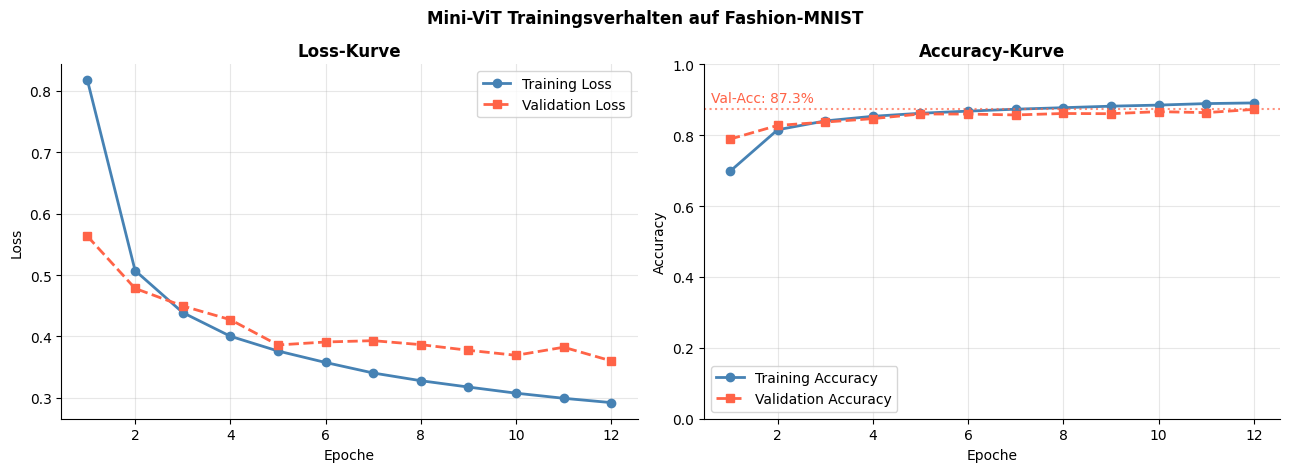


Finale Test-Accuracy: 0.8729 (87.3%)

💡 Einordnung:
   Einfaches MLP:    ~ 87 %
   Dieses Mini-ViT:  ~ 87–89 %  (ohne Pretraining, nur 12 Epochen)
   CNN (Kapitel 10): ~ 92–94 %
   ViT-Large (pretrained): > 99 %


In [14]:
# ── Lernkurven ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs = range(1, len(history.history['loss']) + 1)

# Loss
axes[0].plot(epochs, history.history['loss'],     'o-', color='steelblue',  label='Training Loss', lw=2)
axes[0].plot(epochs, history.history['val_loss'], 's--', color='tomato',   label='Validation Loss', lw=2)
axes[0].set_title('Loss-Kurve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoche'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs, history.history['accuracy'],     'o-',  color='steelblue', label='Training Accuracy', lw=2)
axes[1].plot(epochs, history.history['val_accuracy'], 's--', color='tomato',    label='Validation Accuracy', lw=2)
axes[1].set_title('Accuracy-Kurve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoche'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

# Finale Accuracy annotieren
final_acc = history.history['val_accuracy'][-1]
axes[1].axhline(y=final_acc, color='tomato', ls=':', lw=1.5, alpha=0.7)
axes[1].text(len(epochs) * 0.05, final_acc + 0.02, f'Val-Acc: {final_acc:.1%}', color='tomato', fontsize=10)

plt.tight_layout()
plt.suptitle('Mini-ViT Trainingsverhalten auf Fashion-MNIST', fontsize=12, fontweight='bold', y=1.04)
plt.show()

_, test_acc = model.evaluate(X_test_vit, y_test, verbose=0)
print(f'\nFinale Test-Accuracy: {test_acc:.4f} ({test_acc:.1%})')
print('\n💡 Einordnung:')
print('   Einfaches MLP:    ~ 87 %')
print('   Dieses Mini-ViT:  ~ 87–89 %  (ohne Pretraining, nur 12 Epochen)')
print('   CNN (Kapitel 10): ~ 92–94 %')
print('   ViT-Large (pretrained): > 99 %')

---
## 8 · Attention Maps – Was schaut das Modell an?

Einer der schönsten Aspekte von Vision Transformers ist, dass man  
die **Attention-Gewichte visualisieren** kann – und damit sieht,  
welchen Bildbereichen das Modell Aufmerksamkeit schenkt.

Wir extrahieren die Attention-Gewichte aus dem letzten Transformer-Block  
und legen sie als Heatmap über das Originalbild.

In [15]:
# ── Attention Maps extrahieren ────────────────────────────────────────────────
# Modell mit Attention-Ausgabe neu bauen (Intermediate Model)

class ViTWithAttention(keras.Model):
    """Mini-ViT, der zusätzlich Attention-Weights aus dem letzten Block zurückgibt."""
    def __init__(self, image_size, patch_size, num_patches, d_model,
                 num_heads, num_layers, mlp_dim, dropout, num_classes):
        super().__init__()
        self.patch_extractor = PatchExtractor(patch_size)
        self.embedding       = PatchEmbedding(num_patches, d_model)
        self.blocks          = [TransformerBlock(d_model, num_heads, mlp_dim, dropout)
                                 for _ in range(num_layers)]
        self.norm            = layers.LayerNormalization(epsilon=1e-6)
        self.classifier      = layers.Dense(num_classes, activation='softmax')

    def call(self, x, return_attention=False):
        patches = self.patch_extractor(x)
        x       = self.embedding(patches)
        attn_weights_last = None
        for i, block in enumerate(self.blocks):
            if return_attention and i == len(self.blocks) - 1:
                x, attn_weights_last = block(x, return_attention=True)
            else:
                x = block(x)
        cls = self.norm(x[:, 0, :])
        out = self.classifier(cls)
        if return_attention:
            return out, attn_weights_last
        return out


# Neues Modell bauen und Gewichte vom trainierten Modell kopieren
vit_att = ViTWithAttention(
    IMAGE_SIZE, PATCH_SIZE, NUM_PATCHES,
    D_MODEL, NUM_HEADS, NUM_LAYERS,
    MLP_DIM, DROPOUT, NUM_CLASSES
)
# Dummy-Forward-Pass um Gewichte zu initialisieren
_ = vit_att(X_test_vit[:1])
vit_att.set_weights(model.get_weights())
print('✅ Attention-Modell bereit.')

✅ Attention-Modell bereit.


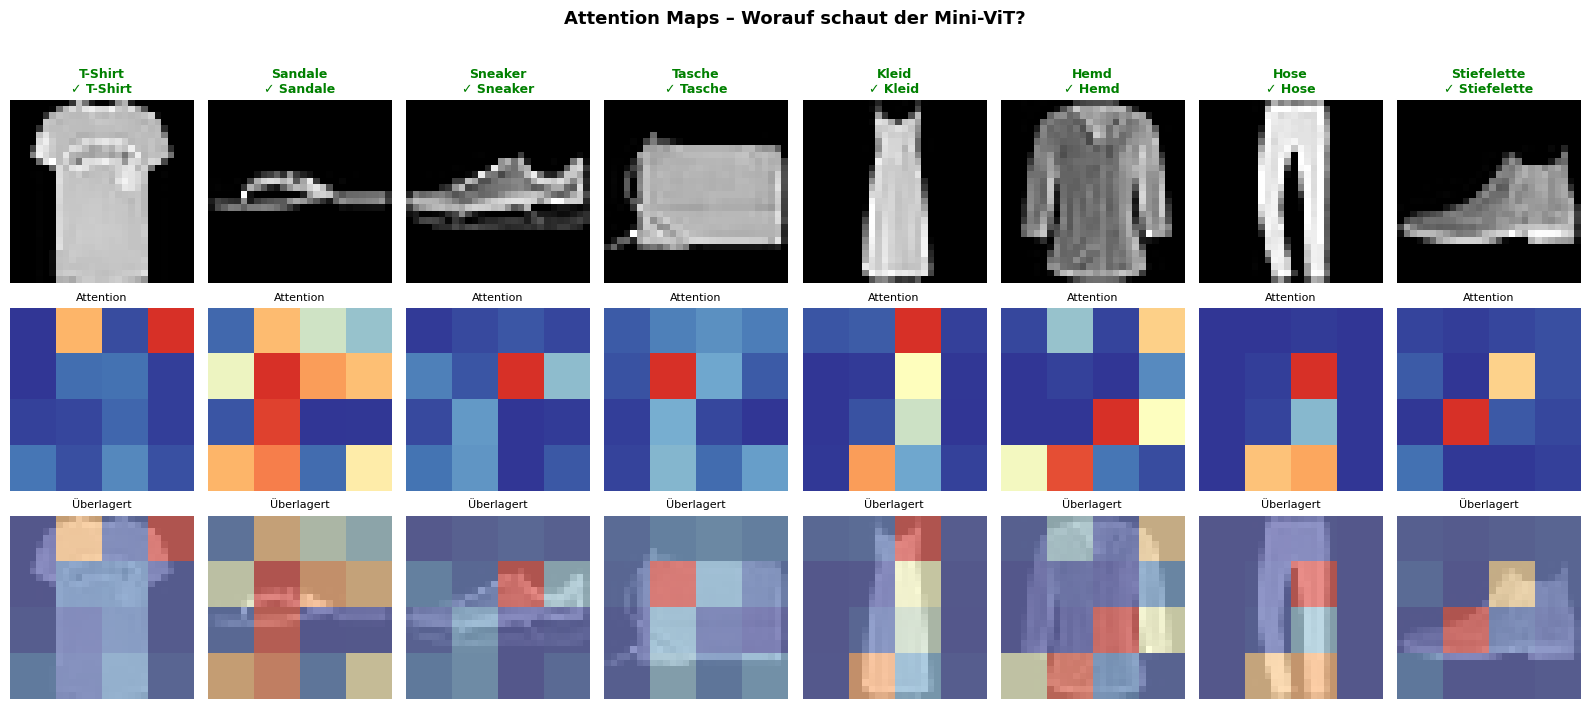

🔴 Rote/warme Bereiche = hohe Attention (das schaut das Modell an)
🔵 Blaue/kühle Bereiche = niedrige Attention

💡 Beobachten Sie: Fokussiert der ViT auf die Objekte – oder den Hintergrund?


In [16]:
# ── Attention Maps visualisieren ─────────────────────────────────────────────
def get_attention_map(image, model, patch_size, n_patches_side):
    """Extrahiert und interpoliert die CLS-Attention auf Bildgröße."""
    img_input = image[np.newaxis, ..., np.newaxis]
    _, attn   = model(img_input, return_attention=True)
    # attn: (batch=1, heads, n_tokens, n_tokens)  n_tokens = num_patches+1
    # CLS-Token: Zeile 0, Spalten 1: → attention auf alle Patches
    cls_attn = attn[0, :, 0, 1:].numpy()  # (heads, num_patches)
    mean_attn = cls_attn.mean(axis=0)      # Mittel über alle Heads
    # Reshape auf Patch-Grid
    attn_map = mean_attn.reshape(n_patches_side, n_patches_side)
    # Hochskalieren auf Bildgröße (nearest neighbor)
    attn_upscaled = np.kron(attn_map, np.ones((patch_size, patch_size)))
    return attn_upscaled, cls_attn


n_side = IMAGE_SIZE // PATCH_SIZE  # 4

# 8 Testbilder (je 2 pro Klasse) auswählen
example_classes = [0, 5, 7, 8, 3, 6, 1, 9]  # T-Shirt, Sandale, Sneaker, Tasche, Kleid, Hemd, Hose, Stiefelette
example_indices = [np.where(y_test == c)[0][0] for c in example_classes]

fig, axes = plt.subplots(3, len(example_classes), figsize=(16, 7))
fig.suptitle('Attention Maps – Worauf schaut der Mini-ViT?', fontsize=13, fontweight='bold', y=1.02)

cmap_attention = LinearSegmentedColormap.from_list('attn',
    ['#313695', '#4575b4', '#74add1', '#ffffbf', '#fdae61', '#f46d43', '#d73027'])

for col, idx in enumerate(example_indices):
    img_ex   = X_test[idx]
    true_cls = class_names[y_test[idx]]

    # Vorhersage
    pred     = model.predict(img_ex[np.newaxis, ..., np.newaxis], verbose=0)
    pred_cls = class_names[np.argmax(pred[0])]
    correct  = '✓' if pred_cls == true_cls else '✗'

    # Attention Map berechnen
    attn_map, head_attn = get_attention_map(img_ex, vit_att, PATCH_SIZE, n_side)

    # Zeile 1: Originalbild
    axes[0, col].imshow(img_ex, cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(f'{true_cls}\n{correct} {pred_cls}',
                            fontsize=9, fontweight='bold',
                            color='green' if correct == '✓' else 'red')
    axes[0, col].axis('off')

    # Zeile 2: Attention Map
    axes[1, col].imshow(attn_map, cmap=cmap_attention)
    axes[1, col].set_title('Attention', fontsize=8)
    axes[1, col].axis('off')

    # Zeile 3: Überlagert
    axes[2, col].imshow(img_ex, cmap='gray', vmin=0, vmax=1, alpha=0.5)
    axes[2, col].imshow(attn_map, cmap=cmap_attention, alpha=0.55)
    axes[2, col].set_title('Überlagert', fontsize=8)
    axes[2, col].axis('off')

# Zeilenbeschriftungen
for row, label in enumerate(['Original', 'Attention Map', 'Überlagert']):
    axes[row, 0].set_ylabel(label, fontsize=10, fontweight='bold', rotation=90, labelpad=10)
    axes[row, 0].yaxis.set_label_position('left')

plt.tight_layout()
plt.show()

print('🔴 Rote/warme Bereiche = hohe Attention (das schaut das Modell an)')
print('🔵 Blaue/kühle Bereiche = niedrige Attention')
print('\n💡 Beobachten Sie: Fokussiert der ViT auf die Objekte – oder den Hintergrund?')

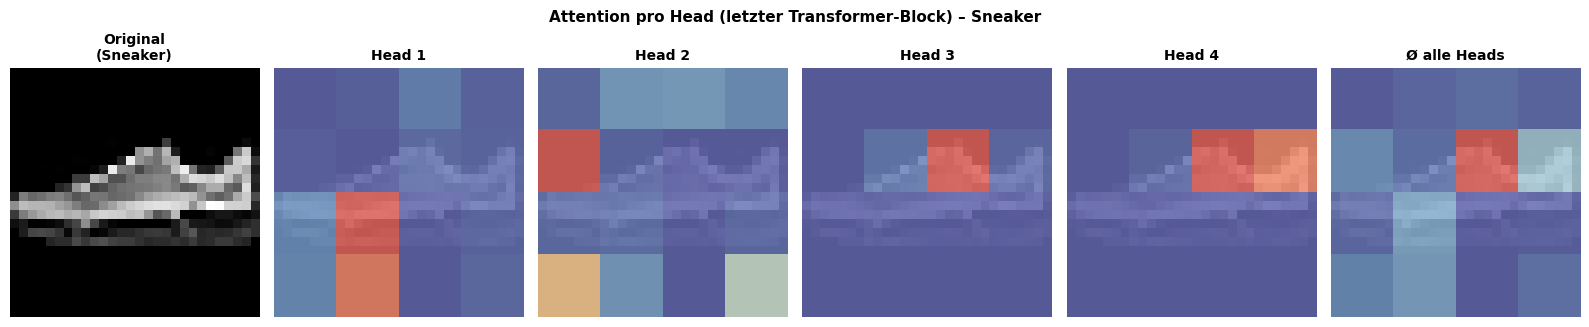

💡 Verschiedene Heads können sich auf unterschiedliche Merkmale spezialisieren:
   Manche schauen auf Konturen, andere auf Texturen oder spezifische Objekt-Teile.


In [17]:
# ── Attention nach Heads aufschlüsseln ───────────────────────────────────────
idx_sample = np.where(y_test == 7)[0][0]  # Sneaker
img_sample = X_test[idx_sample]
_, head_attn = get_attention_map(img_sample, vit_att, PATCH_SIZE, n_side)

fig, axes = plt.subplots(1, NUM_HEADS + 2, figsize=(16, 3.5))

# Original
axes[0].imshow(img_sample, cmap='gray')
axes[0].set_title(f'Original\n(Sneaker)', fontsize=10, fontweight='bold')
axes[0].axis('off')

# Attention pro Head
for h in range(NUM_HEADS):
    head_map = head_attn[h].reshape(n_side, n_side)
    head_map_up = np.kron(head_map, np.ones((PATCH_SIZE, PATCH_SIZE)))

    axes[h + 1].imshow(img_sample, cmap='gray', alpha=0.4)
    axes[h + 1].imshow(head_map_up, cmap=cmap_attention, alpha=0.65)
    axes[h + 1].set_title(f'Head {h+1}', fontsize=10, fontweight='bold')
    axes[h + 1].axis('off')

# Mittelwert aller Heads
mean_map, _ = get_attention_map(img_sample, vit_att, PATCH_SIZE, n_side)
axes[-1].imshow(img_sample, cmap='gray', alpha=0.4)
axes[-1].imshow(mean_map, cmap=cmap_attention, alpha=0.65)
axes[-1].set_title('Ø alle Heads', fontsize=10, fontweight='bold')
axes[-1].axis('off')

plt.suptitle(f'Attention pro Head (letzter Transformer-Block) – Sneaker',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Verschiedene Heads können sich auf unterschiedliche Merkmale spezialisieren:')
print('   Manche schauen auf Konturen, andere auf Texturen oder spezifische Objekt-Teile.')

---
## 9 · Reflexion & Diskussion

### Was haben wir gelernt?

| Konzept | Kernpunkt |
|---------|----------|
| **Patch-Zerlegung** | Bild → Token-Sequenz (wie Wörter in NLP) |
| **Patch Embedding** | Gelernte lineare Projektion der Patches |
| **Positional Embedding** | Kodierung der räumlichen Position |
| **CLS-Token** | Sammelt globale Information für die Klassifikation |
| **Self-Attention** | Jeder Patch schaut auf alle anderen – direkt global |
| **Attention Maps** | Machen das Modell partiell interpretierbar |

---

### Diskussionsfragen

**1. Inductive Bias:**  
CNNs "wissen" durch ihre Architektur, dass Bilder lokal und hierarchisch sind.  
ViTs haben dieses Vorwissen nicht – ist das gut oder schlecht?

**2. Datenbedarf:**  
Unser Mini-ViT erreicht ~88 % auf Fashion-MNIST – ein kleines CNN schafft ~93 %.  
Wie erklären Sie diesen Unterschied bei diesem kleinen Datensatz?

**3. Attention Maps:**  
Schauen die Attention Maps "sinnvoll" aus?  
Welche Bereiche eines Sneakers würden Sie als wichtig erwarten?

**4. Skalierung:**  
Was würde passieren, wenn wir denselben ViT auf 1 Mio. Bilder trainieren könnten?  
Warum profitiert ViT mehr davon als ein CNN?

**5. Praxis:**  
Unter welchen Bedingungen würden Sie in einem echten Projekt ViT statt CNN wählen?

---

### Weiterführende Experimente (optional)

```python
# Experiment 1: Andere Patch-Größe
PATCH_SIZE = 4   # → 49 Patches statt 16 (mehr Tokens, mehr Kontext)

# Experiment 2: Mehr Transformer-Blöcke
NUM_LAYERS = 6   # → tieferes Modell

# Experiment 3: Vortrainiertes ViT-Modell
# from transformers import ViTForImageClassification
# → Hugging Face bietet vortrainierte ViT-Modelle (ViT-B/16, ViT-L/32)

# Experiment 4: CIFAR-10 statt Fashion-MNIST
# → komplexer, Farbbild (3 Kanäle) – zeigt Datenbedarf deutlicher
```

---

### Merksatz

> **Vision Transformers behandeln Bilder als Sequenzen und nutzen Self-Attention,  
> um globale Zusammenhänge direkt zu modellieren.  
> Sie brauchen mehr Daten, skalieren aber besser als CNNs  
> und erreichen dadurch bei großen Datensätzen höhere Performance.**

---
*Kapitel 10 · Bildklassifikation mit Deep Learning · Maschinelles Lernen mit Python*

In [18]:
# ── Letzte Zelle im Notebook ──
total = time.time() - notebook_start
minuten = int(total // 60)
sekunden = int(total % 60)
print(f"Gesamtlaufzeit: {minuten} min {sekunden} sek")

Gesamtlaufzeit: 20 min 33 sek
